# Credit Scoring: Predicting Loan Default

В этом проекте решается задача бинарной классификации: предсказать, будет ли кредит погашен полностью (`Fully Paid`) или перейдёт в дефолт (`Charged Off`).

В проекте выполнены:
- анализ данных (EDA),
- обработка пропусков и аномалий,
- feature engineering,
- обучение нескольких моделей,
- hyperparameter tuning,
- оптимизация threshold,
- интерпретация модели.

**Основная метрика:** ROC-AUC  
**Дополнительные метрики:** Precision, Recall, F1-score

## 1. Imports and settings
Подключаем библиотеки и задаём базовые настройки ноутбука.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 100)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42

## 2. Data loading
Загружаем обучающий и тестовый датасеты из папки `data`.

In [2]:
data_path = Path("data")

train = pd.read_csv(data_path / "credit_train.csv")
test = pd.read_csv(data_path / "credit_test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (100000, 19)
Test shape: (10000, 18)


## 3. Initial data overview
Сначала посмотрим на первые строки таблиц и типы признаков.

In [3]:
train.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6,1,228190,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35,0,229976,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18,1,297996,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9,0,256329,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15,0,253460,427174.0,0.0,0.0


In [4]:
test.head()

,Loan ID,Customer ID,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,f738779f-c726-40dc-92cf-689d73af533d,ded0b3c3-6bf4-4091-8726-47039f2c1b90,611314,Short Term,747.0,2074116.0,10+ years,Home Mortgage,Debt Consolidation,42000.83,21.8,NaN,9,0,621908,1058970,0.0,0.0
1,6dcc0947-164d-476c-a1de-3ae7283dde0a,1630e6e3-34e3-461a-8fda-09297d3140c8,266662,Short Term,734.0,1919190.0,10+ years,Home Mortgage,Debt Consolidation,36624.40,19.4,NaN,11,0,679573,904442,0.0,0.0
2,f7744d01-894b-49c3-8777-fc6431a2cff1,2c60938b-ad2b-4702-804d-eeca43949c52,153494,Short Term,709.0,871112.0,2 years,Rent,Debt Consolidation,8391.73,12.5,10.0,10,0,38532,388036,0.0,0.0
3,83721ffb-b99a-4a0f-aea5-ef472a138b41,12116614-2f3c-4d16-ad34-d92883718806,176242,Short Term,727.0,780083.0,10+ years,Rent,Debt Consolidation,16771.87,16.5,27.0,16,1,156940,531322,1.0,0.0
4,08f3789f-5714-4b10-929d-e1527ab5e5a3,39888105-fd5f-4023-860a-30a3e6f5ccb7,321992,Short Term,744.0,1761148.0,10+ years,Home Mortgage,Debt Consolidation,39478.77,26.0,44.0,14,0,359765,468072,0.0,0.0


In [5]:
train.dtypes

Loan ID                          object
Customer ID                      object
Loan Status                      object
Current Loan Amount               int64
Term                             object
Credit Score                    float64
Annual Income                   float64
Years in current job             object
Home Ownership                   object
Purpose                          object
Monthly Debt                    float64
Years of Credit History         float64
Months since last delinquent    float64
Number of Open Accounts           int64
Number of Credit Problems         int64
Current Credit Balance            int64
Maximum Open Credit             float64
Bankruptcies                    float64
Tax Liens                       float64
dtype: object

## 4. Missing values analysis
Изучим структуру пропусков и проверим важные паттерны missing values.

In [6]:
train.isna().sum().sort_values(ascending=False)

Months since last delinquent    53141
Credit Score                    19154
Annual Income                   19154
Years in current job             4222
Bankruptcies                      204
Tax Liens                          10
Maximum Open Credit                 2
Years of Credit History             0
Current Credit Balance              0
Number of Credit Problems           0
Number of Open Accounts             0
Loan ID                             0
Monthly Debt                        0
Customer ID                         0
Home Ownership                      0
Term                                0
Current Loan Amount                 0
Loan Status                         0
Purpose                             0
dtype: int64

In [7]:
missing_table = pd.DataFrame({
    "missing_count": train.isna().sum(),
})

missing_table["missing_percent"] = (
    missing_table["missing_count"] / len(train) * 100
)

missing_table.sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
Months since last delinquent,53141,53.141
Credit Score,19154,19.154
Annual Income,19154,19.154
Years in current job,4222,4.222
Bankruptcies,204,0.204
Tax Liens,10,0.010
Maximum Open Credit,2,0.002
Years of Credit History,0,0.000
Current Credit Balance,0,0.000
Number of Credit Problems,0,0.000


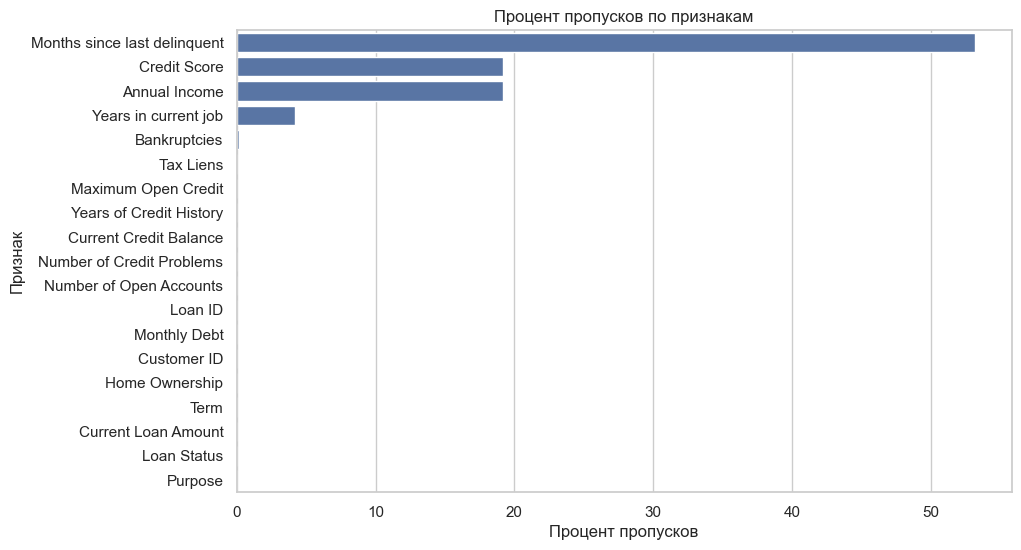

In [8]:
missing_table_sorted = missing_table.sort_values("missing_percent", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    x=missing_table_sorted["missing_percent"],
    y=missing_table_sorted.index
)

plt.title("Процент пропусков по признакам")
plt.xlabel("Процент пропусков")
plt.ylabel("Признак")

plt.show()

In [9]:
(
    train["Credit Score"].isna() ==
    train["Annual Income"].isna()
).value_counts()

True    100000
Name: count, dtype: int64

## 5. Target variable analysis
Проверим баланс классов в целевой переменной.

In [10]:
train["Loan Status"].value_counts()

Loan Status
Fully Paid     77361
Charged Off    22639
Name: count, dtype: int64

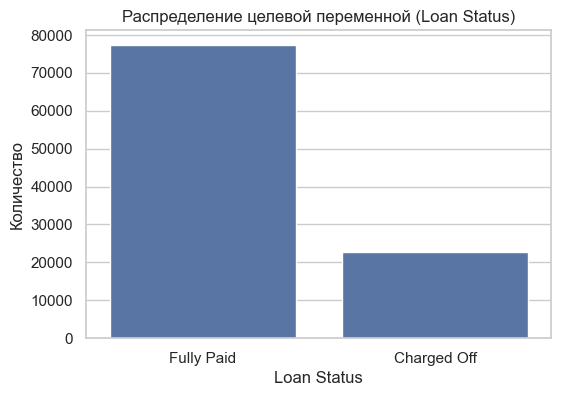

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="Loan Status", data=train)

plt.title("Распределение целевой переменной (Loan Status)")
plt.xlabel("Loan Status")
plt.ylabel("Количество")

plt.show()

## 6. Numerical feature analysis

### 6.1 Current Loan Amount
Начнём с анализа размера кредита и поиска аномалий.

In [12]:
train["Current Loan Amount"].value_counts().head(10)

Current Loan Amount
99999999    11484
223102         27
223322         27
216194         27
223652         27
108966         26
222596         26
214962         25
216810         25
179828         25
Name: count, dtype: int64

In [13]:
train["Current Loan Amount"] = train["Current Loan Amount"].replace(99999999, np.nan)
test["Current Loan Amount"] = test["Current Loan Amount"].replace(99999999, np.nan)

In [14]:
missing_table = pd.DataFrame({
    "missing_count": train.isna().sum(),
})

missing_table["missing_percent"] = (
    missing_table["missing_count"] / len(train) * 100
)

missing_table.sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
Months since last delinquent,53141,53.141
Credit Score,19154,19.154
Annual Income,19154,19.154
Current Loan Amount,11484,11.484
Years in current job,4222,4.222
Bankruptcies,204,0.204
Tax Liens,10,0.010
Maximum Open Credit,2,0.002
Current Credit Balance,0,0.000
Number of Credit Problems,0,0.000


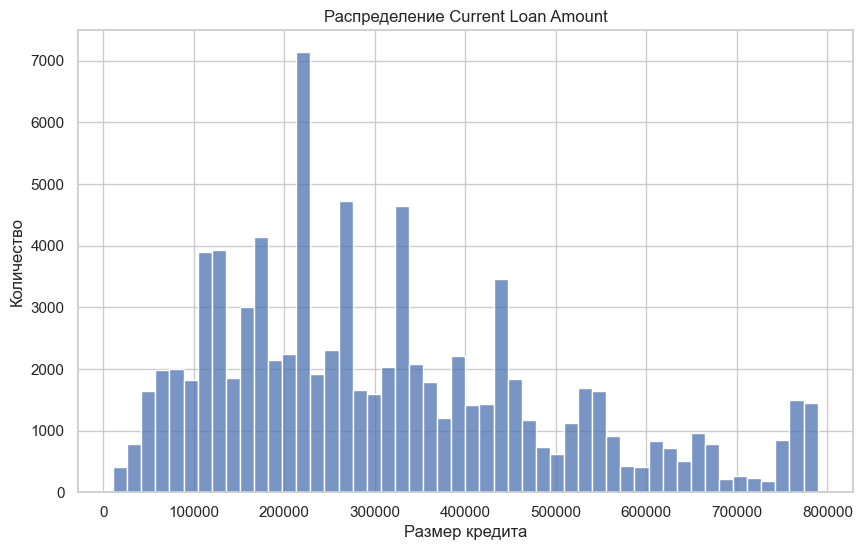

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(train["Current Loan Amount"], bins=50)

plt.title("Распределение Current Loan Amount")
plt.xlabel("Размер кредита")
plt.ylabel("Количество")

plt.show()

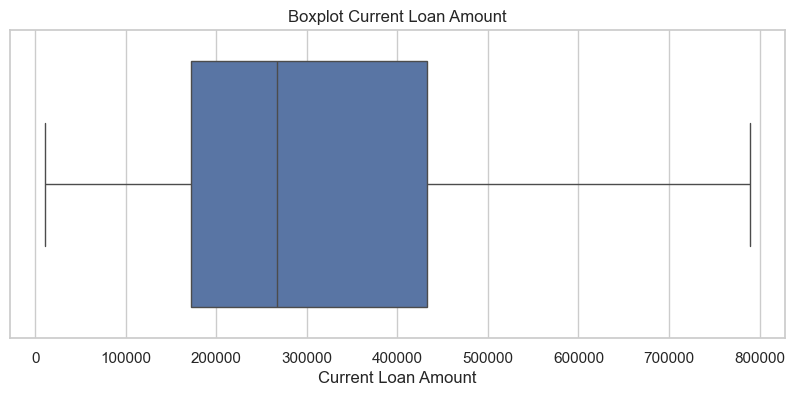

In [16]:
plt.figure(figsize=(10,4))

sns.boxplot(x=train["Current Loan Amount"])

plt.title("Boxplot Current Loan Amount")

plt.show()

### 6.2 Credit Score
Проверим распределение кредитного рейтинга и исправим проблему масштаба.

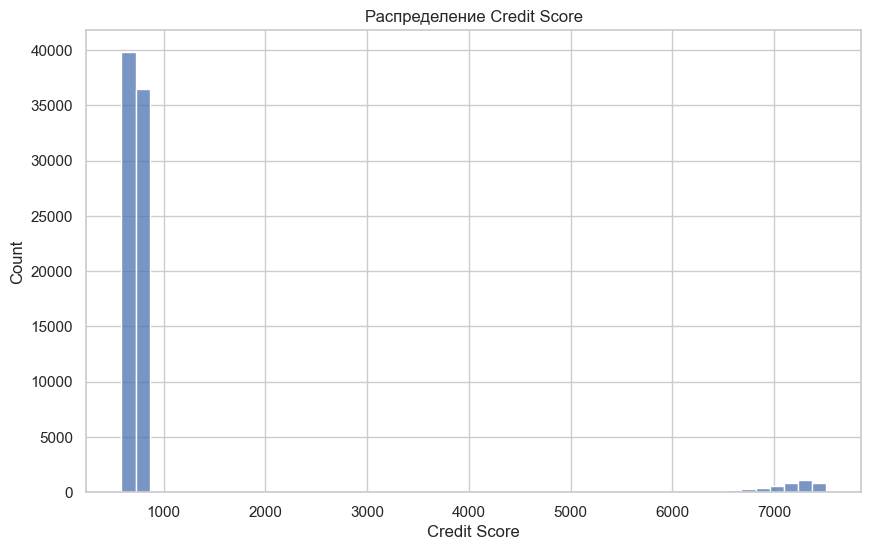

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(train["Credit Score"], bins=50)

plt.title("Распределение Credit Score")
plt.xlabel("Credit Score")

plt.show()

In [18]:
train.loc[train["Credit Score"] > 1000, "Credit Score"] = (
    train.loc[train["Credit Score"] > 1000, "Credit Score"] / 10
)

test.loc[test["Credit Score"] > 1000, "Credit Score"] = (
    test.loc[test["Credit Score"] > 1000, "Credit Score"] / 10
)

In [19]:
train["Credit Score"].describe()

count    80846.000000
mean       716.293447
std         28.297164
min        585.000000
25%        703.000000
50%        722.000000
75%        738.000000
max        751.000000
Name: Credit Score, dtype: float64

### 6.3 Annual Income
Изучим распределение дохода и посмотрим логарифмическое преобразование.

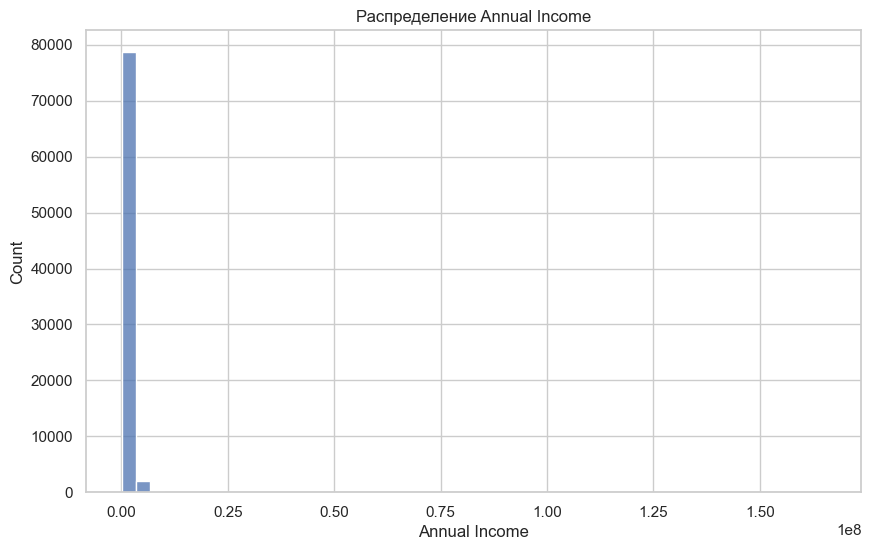

In [20]:
plt.figure(figsize=(10,6))

sns.histplot(train["Annual Income"], bins=50)

plt.title("Распределение Annual Income")
plt.xlabel("Annual Income")

plt.show()

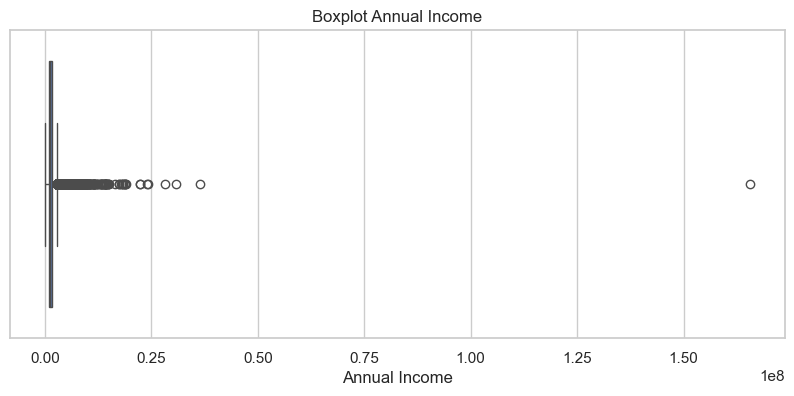

In [21]:
plt.figure(figsize=(10,4))

sns.boxplot(x=train["Annual Income"])

plt.title("Boxplot Annual Income")

plt.show()

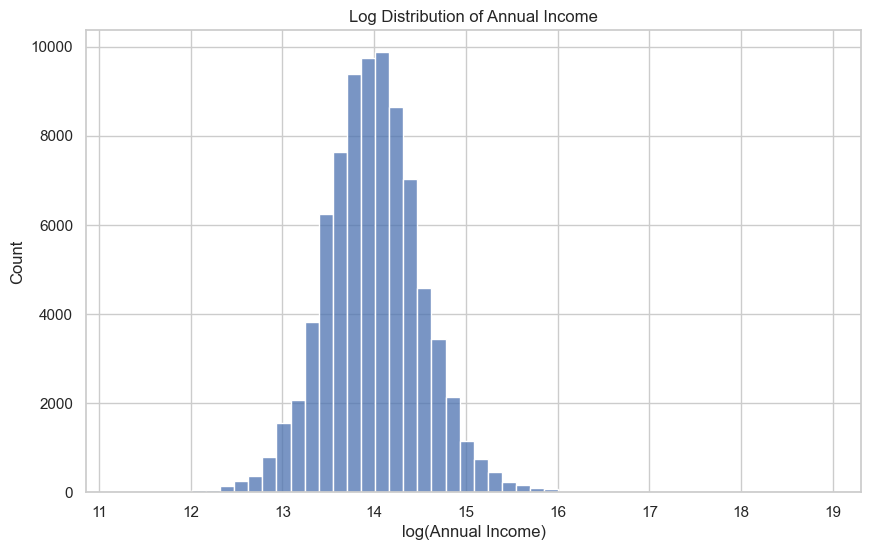

In [22]:
plt.figure(figsize=(10,6))

sns.histplot(np.log1p(train["Annual Income"]), bins=50)

plt.title("Log Distribution of Annual Income")
plt.xlabel("log(Annual Income)")

plt.show()

## 7. Categorical feature analysis

### 7.1 Home Ownership
Проанализируем категории жилья и их связь с дефолтом.

In [23]:
train["Home Ownership"].value_counts()

Home Ownership
Home Mortgage    48410
Rent             42194
Own Home          9182
HaveMortgage       214
Name: count, dtype: int64

In [24]:
train["Home Ownership"] = train["Home Ownership"].replace(
    {"HaveMortgage": "Home Mortgage"}
)

test["Home Ownership"] = test["Home Ownership"].replace(
    {"HaveMortgage": "Home Mortgage"}
)

In [25]:
pd.crosstab(
    train["Home Ownership"],
    train["Loan Status"],
    normalize="index"
)

Loan Status,Charged Off,Fully Paid
Home Ownership,,
Home Mortgage,0.204446,0.795554
Own Home,0.228926,0.771074
Rent,0.251126,0.748874


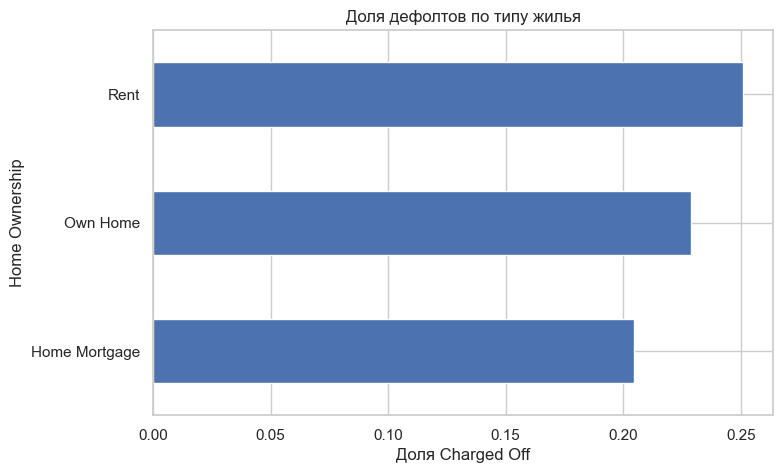

In [26]:
default_rate = pd.crosstab(
    train["Home Ownership"],
    train["Loan Status"],
    normalize="index"
)

default_rate["Charged Off"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Доля дефолтов по типу жилья")
plt.xlabel("Доля Charged Off")

plt.show()

### 7.2 Purpose
Проанализируем цель кредита и долю дефолтов в разных категориях.

In [27]:
train["Purpose"].value_counts()

Purpose
Debt Consolidation      78552
other                    6037
Home Improvements        5839
Other                    3250
Business Loan            1569
Buy a Car                1265
Medical Bills            1127
Buy House                 678
Take a Trip               573
major_purchase            352
small_business            283
moving                    150
wedding                   115
vacation                  101
Educational Expenses       99
renewable_energy           10
Name: count, dtype: int64

In [28]:
train["Purpose"] = train["Purpose"].replace({"other": "Other"})
test["Purpose"] = test["Purpose"].replace({"other": "Other"})

In [29]:
purpose_default = pd.crosstab(
    train["Purpose"],
    train["Loan Status"],
    normalize="index"
)

purpose_default.sort_values("Charged Off", ascending=False)

Loan Status,Charged Off,Fully Paid
Purpose,,
small_business,0.420495,0.579505
renewable_energy,0.400000,0.600000
Business Loan,0.304653,0.695347
vacation,0.287129,0.712871
moving,0.286667,0.713333
Medical Bills,0.246673,0.753327
major_purchase,0.232955,0.767045
Debt Consolidation,0.228104,0.771896
Other,0.218154,0.781846


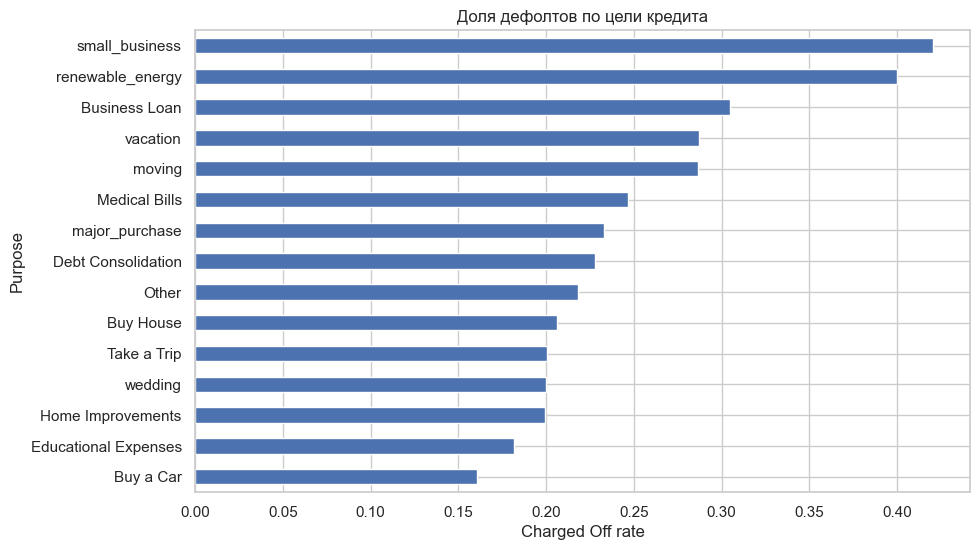

In [30]:
plt.figure(figsize=(10,6))

purpose_default["Charged Off"].sort_values().plot(kind="barh")

plt.title("Доля дефолтов по цели кредита")
plt.xlabel("Charged Off rate")

plt.show()

## 8. Data cleaning and feature engineering

На основе EDA выполняем очистку данных и создаём новые признаки.

In [31]:
train["Months since last delinquent"] = train["Months since last delinquent"].fillna(999)
test["Months since last delinquent"] = test["Months since last delinquent"].fillna(999)

In [32]:
def convert_job_years(value):
    
    if pd.isna(value):
        return np.nan
    
    if value == "< 1 year":
        return 0
    
    if value == "10+ years":
        return 10
    
    return int(value.split()[0])


train["Years in current job"] = train["Years in current job"].apply(convert_job_years)
test["Years in current job"] = test["Years in current job"].apply(convert_job_years)

In [33]:
median_job_years = train["Years in current job"].median()

train["Years in current job"] = train["Years in current job"].fillna(median_job_years)
test["Years in current job"] = test["Years in current job"].fillna(median_job_years)

In [34]:
train["Debt_to_Income"] = train["Monthly Debt"] / train["Annual Income"]
test["Debt_to_Income"] = test["Monthly Debt"] / test["Annual Income"]

### 8.1 Target encoding and additional features
Кодируем target, преобразуем `Term` и создаём engineered features.

In [35]:
train["Loan Status"] = train["Loan Status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

In [36]:
train["Term"] = train["Term"].map({
    "Short Term": 0,
    "Long Term": 1
})

test["Term"] = test["Term"].map({
    "Short Term": 0,
    "Long Term": 1
})

In [37]:
train["income_credit_missing"] = train["Annual Income"].isna().astype(int)
test["income_credit_missing"] = test["Annual Income"].isna().astype(int)

In [38]:
train["log_annual_income"] = np.log1p(train["Annual Income"])
test["log_annual_income"] = np.log1p(test["Annual Income"])

In [39]:
train["credit_utilization"] = train["Current Credit Balance"] / train["Maximum Open Credit"]
test["credit_utilization"] = test["Current Credit Balance"] / test["Maximum Open Credit"]

In [44]:
train["log_credit_balance"] = np.log1p(train["Current Credit Balance"])
test["log_credit_balance"] = np.log1p(test["Current Credit Balance"])

In [45]:
train = train.replace([np.inf, -np.inf], np.nan)
test = test.replace([np.inf, -np.inf], np.nan)

In [47]:
numeric_cols = train.select_dtypes(include=[np.number]).columns

for col in numeric_cols:

    median_value = train[col].median()

    train[col] = train[col].fillna(median_value)

    if col in test.columns:
        test[col] = test[col].fillna(median_value)

## 9. Final dataset preparation
Удаляем ID-признаки и формируем `X` и `y`.

In [48]:
train = train.drop(columns=["Loan ID", "Customer ID"])
test = test.drop(columns=["Loan ID", "Customer ID"])

In [49]:
X = train.drop(columns="Loan Status")
y = train["Loan Status"]

## 10. Preprocessing pipeline
Настраиваем обработку числовых и категориальных признаков через `ColumnTransformer`.

In [50]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=[np.number]).columns

print("Categorical:", categorical_cols)
print()
print("Numeric:", numeric_cols)

Categorical: Index(['Home Ownership', 'Purpose'], dtype='object')

Numeric: Index(['Current Loan Amount', 'Term', 'Credit Score', 'Annual Income', 'Years in current job', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Credit', 'Bankruptcies', 'Tax Liens', 'Debt_to_Income', 'income_credit_missing', 'log_annual_income',
       'credit_utilization', 'log_credit_balance'],
      dtype='object')


In [51]:
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

## 11. Train / validation split
Делим данные на обучающую и валидационную выборки со стратификацией.

In [52]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

## 12. Baseline models

### 12.1 Logistic Regression

In [53]:
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Current Loan Amount', 'Term', 'Credit Score', 'Annual Income', 'Years in current job', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Credit', 'Bankruptcies', 'Tax Liens', 'Debt_to_Income', 'income_credit_missing', 'log_annual_income',
       'credit_utilization', 'log_credit_balance'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Home Ownership', 'Purpose'], dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [54]:
y_pred = log_reg_pipeline.predict(X_valid)
y_proba = log_reg_pipeline.predict_proba(X_valid)[:, 1]

In [55]:
print("Accuracy:", accuracy_score(y_valid, y_pred))
print("Precision:", precision_score(y_valid, y_pred))
print("Recall:", recall_score(y_valid, y_pred))
print("F1-score:", f1_score(y_valid, y_pred))
print("ROC-AUC:", roc_auc_score(y_valid, y_proba))

Accuracy: 0.58765
Precision: 0.2975944269075868
Recall: 0.6037985865724381
F1-score: 0.3986875683558148
ROC-AUC: 0.6303510404980981


### 12.2 Random Forest

In [56]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Current Loan Amount', 'Term', 'Credit Score', 'Annual Income', 'Years in current job', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Cr...x Liens', 'Debt_to_Income', 'income_credit_missing', 'log_annual_income',
       'credit_utilization', 'log_credit_balance'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Home Ownership', 'Purpose'], dtype='object'))])),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [57]:
y_pred_rf = rf_pipeline.predict(X_valid)
y_proba_rf = rf_pipeline.predict_proba(X_valid)[:, 1]

In [58]:
print("Accuracy:", accuracy_score(y_valid, y_pred_rf))
print("Precision:", precision_score(y_valid, y_pred_rf))
print("Recall:", recall_score(y_valid, y_pred_rf))
print("F1-score:", f1_score(y_valid, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_valid, y_proba_rf))

Accuracy: 0.77345
Precision: 0.4117647058823529
Recall: 0.0015459363957597172
F1-score: 0.0030803080308030805
ROC-AUC: 0.6923939569622635


### 12.3 Gradient Boosting

In [59]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ))
])

gb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Current Loan Amount', 'Term', 'Credit Score', 'Annual Income', 'Years in current job', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Cr...x Liens', 'Debt_to_Income', 'income_credit_missing', 'log_annual_income',
       'credit_utilization', 'log_credit_balance'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Home Ownership', 'Purpose'], dtype='object'))])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=200,
                                            random_state=42))])

In [60]:
y_pred_gb = gb_pipeline.predict(X_valid)
y_proba_gb = gb_pipeline.predict_proba(X_valid)[:, 1]

In [61]:
print("Accuracy:", accuracy_score(y_valid, y_pred_gb))
print("Precision:", precision_score(y_valid, y_pred_gb))
print("Recall:", recall_score(y_valid, y_pred_gb))
print("F1-score:", f1_score(y_valid, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_valid, y_proba_gb))

Accuracy: 0.7737
Precision: 0.5094339622641509
Recall: 0.011925795053003533
F1-score: 0.02330599913681485
ROC-AUC: 0.6974994695764102


## 13. Threshold analysis for baseline Gradient Boosting
Проверим, как меняются Precision / Recall / F1 при разных порогах.

In [62]:
thresholds = [0.5, 0.4, 0.3, 0.2, 0.15, 0.1]

for t in thresholds:
    
    y_pred_t = (y_proba_gb >= t).astype(int)
    
    print(f"\nThreshold = {t}")
    print("Precision:", precision_score(y_valid, y_pred_t))
    print("Recall:", recall_score(y_valid, y_pred_t))
    print("F1:", f1_score(y_valid, y_pred_t))


Threshold = 0.5
Precision: 0.5094339622641509
Recall: 0.011925795053003533
F1: 0.02330599913681485

Threshold = 0.4
Precision: 0.48092369477911645
Recall: 0.10578621908127209
F1: 0.17342505430847213

Threshold = 0.3
Precision: 0.3968932913102206
Recall: 0.38935512367491165
F1: 0.3930880713489409

Threshold = 0.2
Precision: 0.29583462372251473
Recall: 0.8438604240282686
F1: 0.43808759458839713

Threshold = 0.15
Precision: 0.26994896053778167
Recall: 0.9578180212014135
F1: 0.42119063804991747

Threshold = 0.1
Precision: 0.25880665519219737
Recall: 0.9962455830388692
F1: 0.410875307405046


## 14. Hyperparameter tuning
Подбираем лучшие параметры `GradientBoostingClassifier` через `RandomizedSearchCV` со `StratifiedKFold`.

In [63]:
param_dist = {
    "model__n_estimators": [200, 300, 400, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_leaf": [1, 3, 5],
    "model__subsample": [0.7, 0.8, 0.9, 1.0]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

random_search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['Current Loan Amount', 'Term', 'Credit Score', 'Annual Income', 'Years in current job', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinque...
                                              GradientBoostingClassifier(learning_rate=0.05,
                                                                         n_estimators=200,
                                                                         random_state=42))]),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1],
                                        'model__max_depth': [2, 3, 4],
                                        'model__min_samples_leaf': [1, 3, 5],
                                        'model__n_estimators': [200, 300, 400,
                                                                500],
                                        'model__subsample': [0.7, 0.8, 0.9,
                                                             1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [64]:
random_search.best_params_

{'model__subsample': 0.9,
 'model__n_estimators': 300,
 'model__min_samples_leaf': 1,
 'model__max_depth': 4,
 'model__learning_rate': 0.1}

In [65]:
random_search.best_score_

0.7023685356498734

## 15. Final tuned model
Обучаем модель с лучшими найденными гиперпараметрами и оцениваем её на validation.

In [66]:
best_gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=4,
        min_samples_leaf=1,
        subsample=0.9,
        random_state=RANDOM_STATE
    ))
])

best_gb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Current Loan Amount', 'Term', 'Credit Score', 'Annual Income', 'Years in current job', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Cr..., 'Debt_to_Income', 'income_credit_missing', 'log_annual_income',
       'credit_utilization', 'log_credit_balance'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Home Ownership', 'Purpose'], dtype='object'))])),
                ('model',
                 GradientBoostingClassifier(max_depth=4, n_estimators=300,
                                            random_state=42, subsample=0.9))])

In [67]:
y_pred_final = best_gb_pipeline.predict(X_valid)
y_proba_final = best_gb_pipeline.predict_proba(X_valid)[:, 1]

In [68]:
print("Accuracy:", accuracy_score(y_valid, y_pred_final))
print("Precision:", precision_score(y_valid, y_pred_final))
print("Recall:", recall_score(y_valid, y_pred_final))
print("F1-score:", f1_score(y_valid, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_valid, y_proba_final))

Accuracy: 0.77555
Precision: 0.5428571428571428
Recall: 0.05454946996466431
F1-score: 0.09913706602448324
ROC-AUC: 0.7047128164499143


## 16. Threshold optimization for final model
Выбираем рабочий threshold с акцентом на Recall для задачи кредитного скоринга.

In [69]:
thresholds = [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1]

for t in thresholds:
    
    y_pred_t = (y_proba_final >= t).astype(int)
    
    print(f"\nThreshold = {t}")
    print("Precision:", precision_score(y_valid, y_pred_t))
    print("Recall:", recall_score(y_valid, y_pred_t))
    print("F1:", f1_score(y_valid, y_pred_t))


Threshold = 0.5
Precision: 0.5428571428571428
Recall: 0.05454946996466431
F1: 0.09913706602448324

Threshold = 0.4
Precision: 0.46307956496851743
Recall: 0.1786660777385159
F1: 0.25784860557768924

Threshold = 0.3
Precision: 0.3903702282754652
Recall: 0.4494257950530035
F1: 0.41782157889333743

Threshold = 0.25
Precision: 0.34514023210831724
Recall: 0.6305212014134276
F1: 0.44609375

Threshold = 0.2
Precision: 0.3076400679117148
Recall: 0.8003533568904594
F1: 0.4444444444444444

Threshold = 0.15
Precision: 0.28053115149889346
Recall: 0.9238074204946997
F1: 0.4303719327125881

Threshold = 0.1
Precision: 0.2637927975873692
Recall: 0.9852031802120141
F1: 0.4161574700312515


In [81]:
best_threshold = 0.2

y_pred_best = (y_proba_final >= best_threshold).astype(int)

print("Precision:", precision_score(y_valid, y_pred_best))
print("Recall:", recall_score(y_valid, y_pred_best))
print("F1:", f1_score(y_valid, y_pred_best))

Precision: 0.3076400679117148
Recall: 0.8003533568904594
F1: 0.4444444444444444


## 17. Model interpretation
Посмотрим на важность признаков у финальной модели.

In [71]:
feature_names = best_gb_pipeline.named_steps["preprocessor"].get_feature_names_out()


importances = best_gb_pipeline.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance = feature_importance.sort_values("importance", ascending=False)

feature_importance.head(20)

,feature,importance
0,num__Current Loan Amount,0.306197
2,num__Credit Score,0.105103
1,num__Term,0.071577
14,num__Debt_to_Income,0.070556
17,num__credit_utilization,0.058852
11,num__Maximum Open Credit,0.051011
16,num__log_annual_income,0.050855
3,num__Annual Income,0.046113
6,num__Years of Credit History,0.042841
5,num__Monthly Debt,0.034834


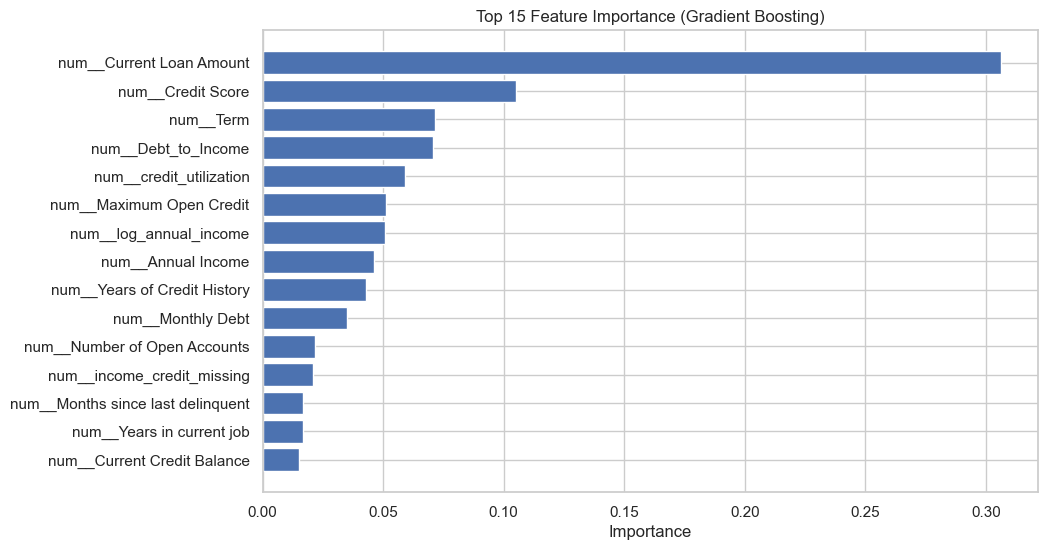

In [72]:
plt.figure(figsize=(10,6))

top_features = feature_importance.head(15)

plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance (Gradient Boosting)")
plt.xlabel("Importance")

plt.show()

## 18. Train final model on full train data
После выбора параметров и threshold обучаем модель на всём train датасете.

In [73]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=4,
        min_samples_leaf=1,
        subsample=0.9,
        random_state=RANDOM_STATE
    ))
])

final_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Current Loan Amount', 'Term', 'Credit Score', 'Annual Income', 'Years in current job', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Cr..., 'Debt_to_Income', 'income_credit_missing', 'log_annual_income',
       'credit_utilization', 'log_credit_balance'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Home Ownership', 'Purpose'], dtype='object'))])),
                ('model',
                 GradientBoostingClassifier(max_depth=4, n_estimators=300,
                                            random_state=42, subsample=0.9))])

In [74]:
test_proba = final_model.predict_proba(test)[:, 1]

In [75]:
best_threshold = 0.2

y_pred_best = (y_proba_final >= best_threshold).astype(int)


print("Accuracy :", accuracy_score(y_valid, y_pred_best))
print("Precision:", precision_score(y_valid, y_pred_best))
print("Recall   :", recall_score(y_valid, y_pred_best))
print("F1-score :", f1_score(y_valid, y_pred_best))
print("ROC-AUC  :", roc_auc_score(y_valid, y_proba_final))

Accuracy : 0.547
Precision: 0.3076400679117148
Recall   : 0.8003533568904594
F1-score : 0.4444444444444444
ROC-AUC  : 0.7047128164499143


## 19. Final evaluation plots
Строим ROC curve, Confusion Matrix и Precision-Recall curve.

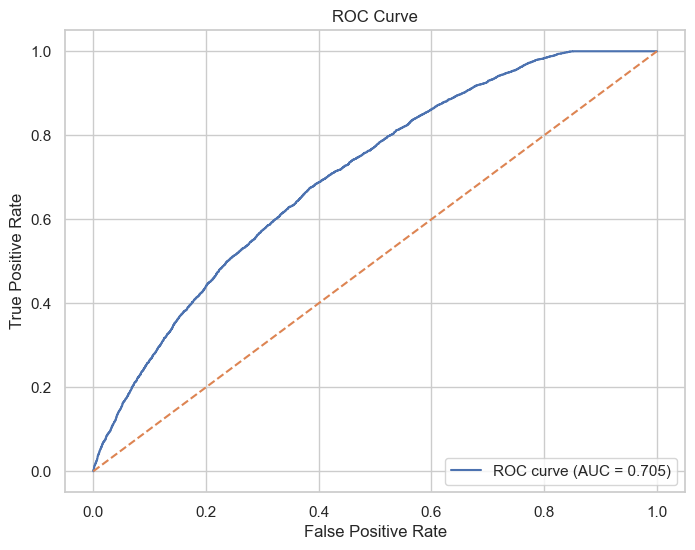

In [76]:
fpr, tpr, _ = roc_curve(y_valid, y_proba_final)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

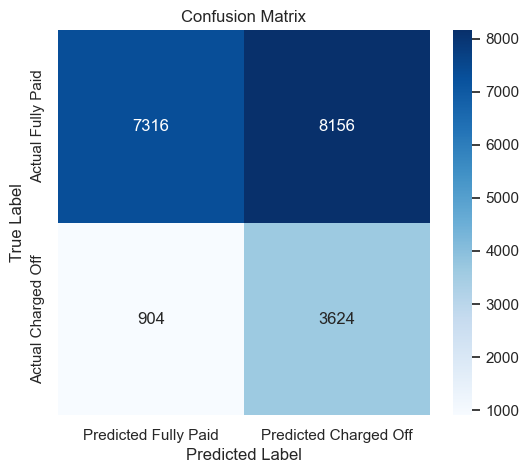

In [77]:
cm = confusion_matrix(y_valid, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Fully Paid", "Predicted Charged Off"],
    yticklabels=["Actual Fully Paid", "Actual Charged Off"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

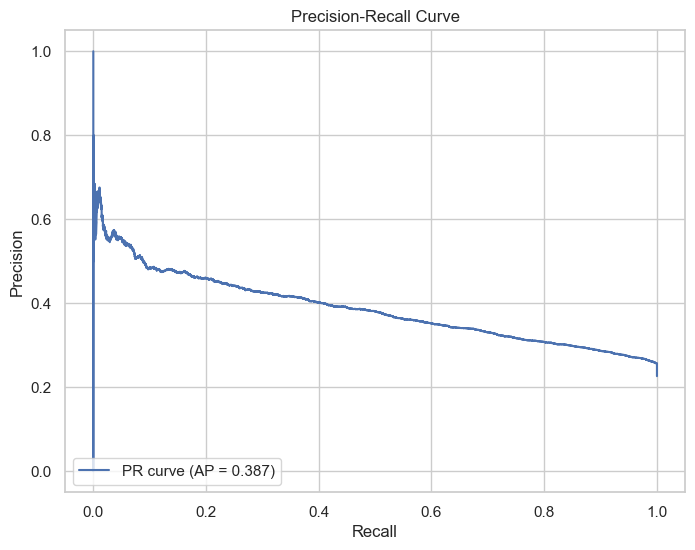

In [78]:
precision, recall, _ = precision_recall_curve(y_valid, y_proba_final)
ap_score = average_precision_score(y_valid, y_proba_final)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"PR curve (AP = {ap_score:.3f})")

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid(True)

plt.show()

## 20. Prediction for test dataset
Формируем итоговый файл с предсказаниями.

In [83]:
best_threshold = 0.2

test_predictions = (test_proba >= best_threshold).astype(int)

In [84]:
submission = pd.DataFrame({
    "Loan Status": test_predictions
})

submission.to_csv("submission.csv", index=False)

